In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [3]:
df=pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


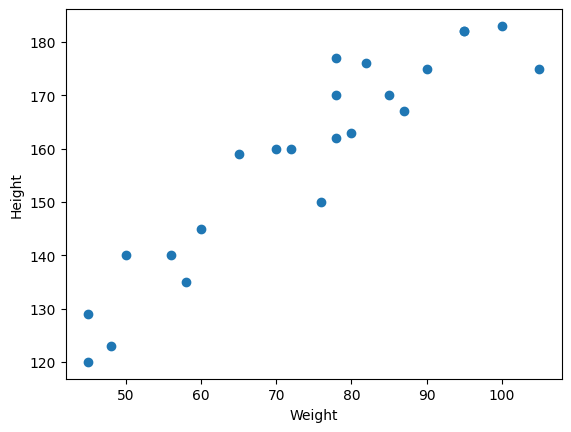

In [4]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")
df.corr()

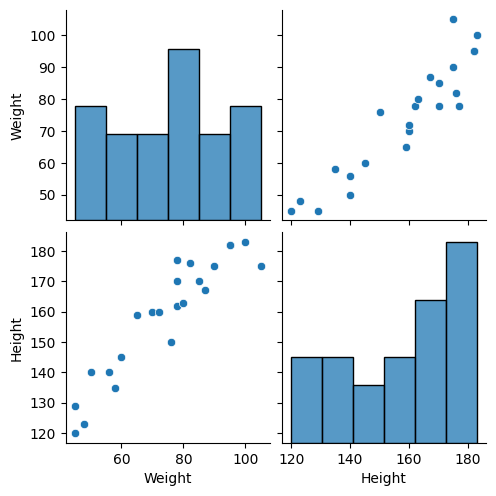

In [6]:
import seaborn as sns
sns.pairplot(df)

In [7]:
X=df[['Weight']]
type(X)
X

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [8]:
y=df['Height']
type(y)
y

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [10]:
X_train.shape

(17, 1)

In [11]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [61]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [12]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression(n_jobs=-1)
regression.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [13]:
print(regression.coef_) #one feature,one slope

[1.04792503]


In [14]:
print(regression.intercept_)

80.52684512622542


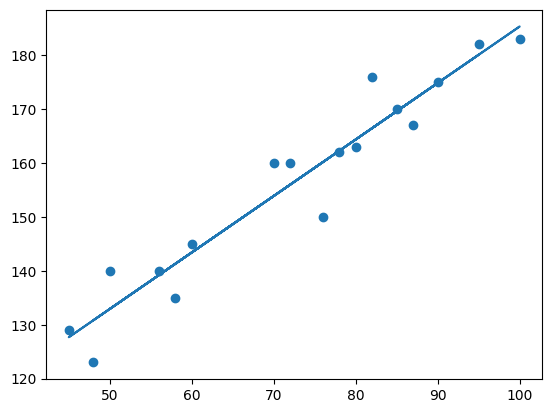

In [15]:
#best fit line 
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train)) 

In [16]:
y_pred=regression.predict(X_test)

In [17]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228686
9.665125886795005
10.7163749912126


In [18]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)

In [19]:
print(score)

0.7360826717981279


In [20]:
1-(1-score)*(len(y_test-1)/(len(y_test)-X_test.shape[1]-1))

0.6041240076971919

In [79]:
regression.predict(scaler.transform([[72]]))

C:\Users\KASHISH\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])

In [21]:
#Residuals
residuals=y_test-y_pred

In [22]:
residuals

15    14.735003
9      7.735003
0     -7.683471
8      1.920277
17    10.358028
12   -15.558973
Name: Height, dtype: float64

C:\Users\KASHISH\AppData\Local\Temp\ipykernel_13164\3421770756.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<Axes: xlabel='Height', ylabel='Density'>

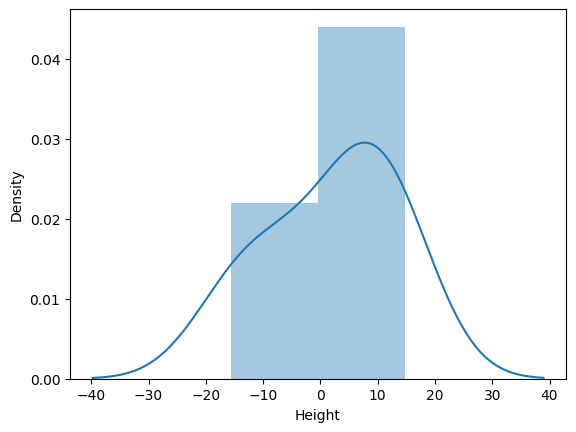

In [23]:
import seaborn as sns
sns.distplot(residuals,kde=True)
